In [2]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import KBinsDiscretizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer as knn
import pandas as pd
import numpy as np


In [47]:
data=pd.read_csv(r'Data\data_to_train.csv', sep=',')

In [48]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5975 non-null   str    
 1   Year               5975 non-null   int64  
 2   Kilometers_Driven  5975 non-null   int64  
 3   Fuel_Type          5975 non-null   str    
 4   Transmission       5975 non-null   str    
 5   Owner_Type         5975 non-null   str    
 6   Consumation        5975 non-null   float64
 7   Engine             5975 non-null   int64  
 8   Power              5975 non-null   float64
 9   Seats              5975 non-null   int64  
 10  Price              5975 non-null   float64
 11  Brand              5975 non-null   str    
 12  Model              5975 non-null   str    
 13  car_age            5975 non-null   int64  
 14  km/age             5975 non-null   float64
dtypes: float64(4), int64(5), str(6)
memory usage: 700.3 KB


In [49]:
data.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Consumation,Engine,Power,Seats,Price,Brand,Model,car_age,km/age
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5,1.75,Maruti,Wagon R LXI CNG,16,4500.000000
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5,12.50,Hyundai,Creta 1.6 CRDi SX Option,11,3727.272727
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5,4.50,Honda,Jazz V,15,3066.666667
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7,6.00,Maruti,Ertiga VDI,14,6214.285714
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5,17.74,Audi,A4 New 2.0 TDI Multitronic,13,3128.461538


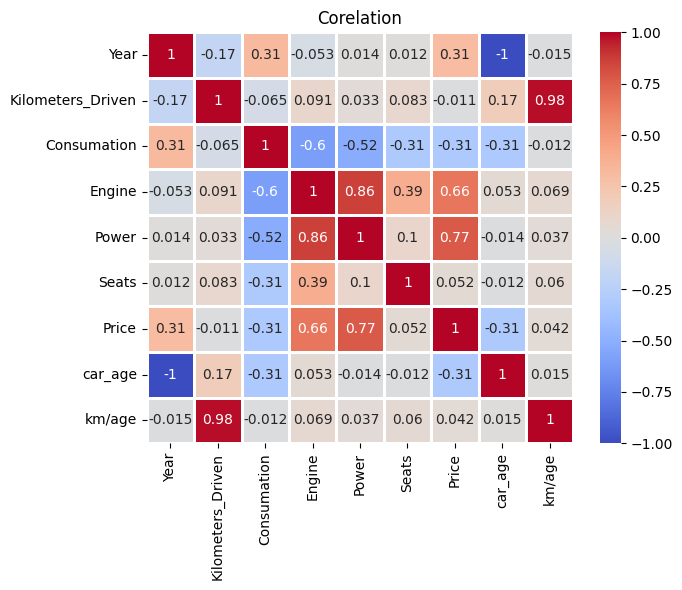

In [50]:
cor = data.corr(numeric_only=True)
plt.figure(figsize=(7,6))
sns.heatmap(cor , 
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            # cbar_kws={'shrink': 0.8}
            )
plt.title('Corelation')
plt.tight_layout()
plt.show()

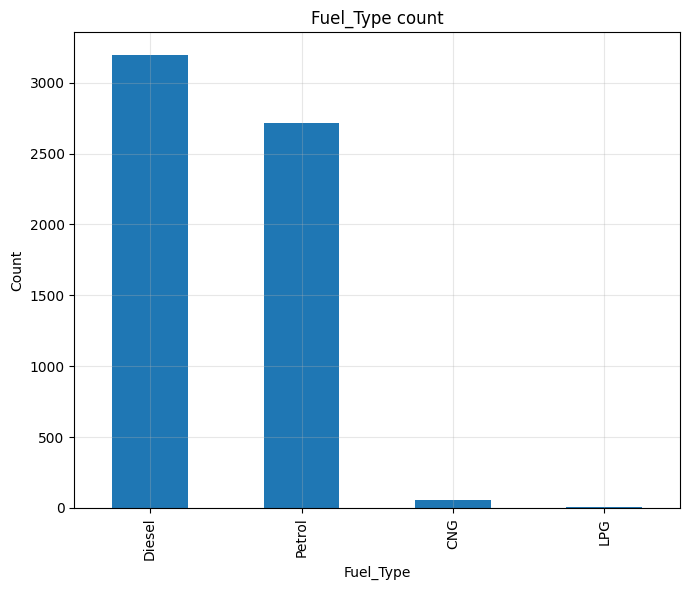

In [51]:
plt.figure(figsize=(7,6))
data['Fuel_Type'].value_counts().plot(kind='bar')
plt.title('Fuel_Type count')
plt.xlabel('Fuel_Type')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# suppresion des fuels peut representer

In [52]:
data.drop(data.loc[data['Fuel_Type'] == 'CNG'].index, inplace=True)
data.drop(data.loc[data['Fuel_Type'] == 'LPG'].index, inplace=True)

In [53]:
data.info( )

<class 'pandas.DataFrame'>
Index: 5909 entries, 1 to 5974
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5909 non-null   str    
 1   Year               5909 non-null   int64  
 2   Kilometers_Driven  5909 non-null   int64  
 3   Fuel_Type          5909 non-null   str    
 4   Transmission       5909 non-null   str    
 5   Owner_Type         5909 non-null   str    
 6   Consumation        5909 non-null   float64
 7   Engine             5909 non-null   int64  
 8   Power              5909 non-null   float64
 9   Seats              5909 non-null   int64  
 10  Price              5909 non-null   float64
 11  Brand              5909 non-null   str    
 12  Model              5909 non-null   str    
 13  car_age            5909 non-null   int64  
 14  km/age             5909 non-null   float64
dtypes: float64(4), int64(5), str(6)
memory usage: 738.6 KB


In [54]:
data["power/horse"] = (data["Power"]/data["Engine"])*100

In [55]:
data.drop(columns=['Power',"Engine","Year","Kilometers_Driven","km/age"], inplace=True)

In [56]:
data.head()

,Location,Fuel_Type,Transmission,Owner_Type,Consumation,Seats,Price,Brand,Model,car_age,power/horse
1,Pune,Diesel,Manual,First,19.67,5,12.50,Hyundai,Creta 1.6 CRDi SX Option,11,7.977244
2,Chennai,Petrol,Manual,First,18.20,5,4.50,Honda,Jazz V,15,7.397832
3,Chennai,Diesel,Manual,First,20.77,7,6.00,Maruti,Ertiga VDI,14,7.112179
4,Coimbatore,Diesel,Automatic,Second,15.20,5,17.74,Audi,A4 New 2.0 TDI Multitronic,13,7.154472
6,Jaipur,Diesel,Manual,First,23.08,5,3.50,Nissan,Micra Diesel XV,13,4.318960


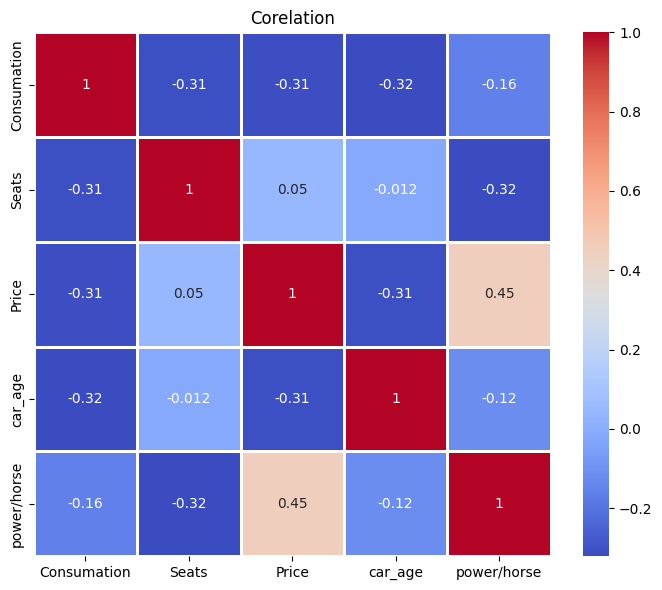

In [57]:
cor = data.corr(numeric_only=True)
plt.figure(figsize=(7,6))
sns.heatmap(cor , 
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            # cbar_kws={'shrink': 0.8}
            )
plt.title('Corelation')
plt.tight_layout()
plt.show()

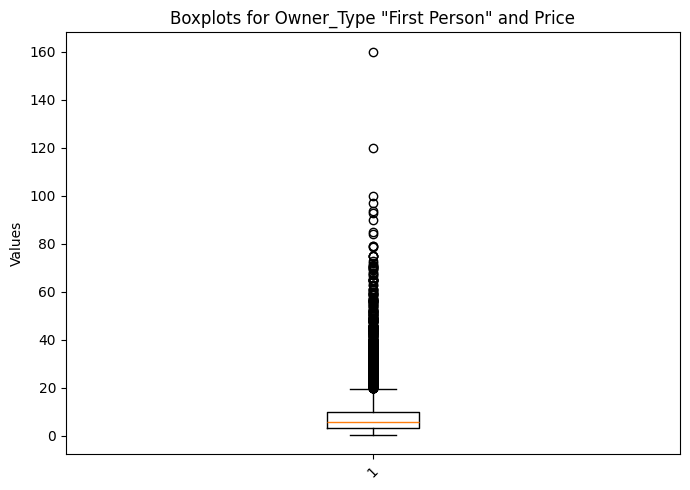

In [60]:


plt.figure(figsize=(7, 5))
plt.boxplot(data["Price"])
plt.xticks(rotation=45)
plt.title('Boxplots for Owner_Type "First Person" and Price')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

# supression des voitures de plus de 80 000 

In [69]:
dataf= data.drop(data[data['Price'] > 80].index)

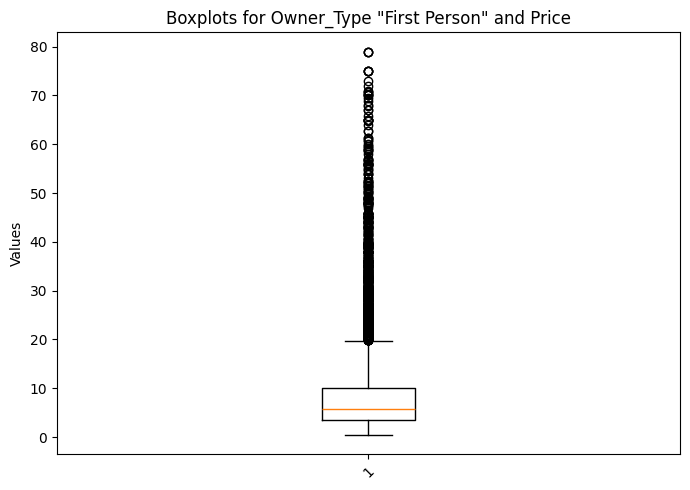

In [70]:
plt.figure(figsize=(7, 5))
plt.boxplot(dataf["Price"])
plt.xticks(rotation=45)
plt.title('Boxplots for Owner_Type "First Person" and Price')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

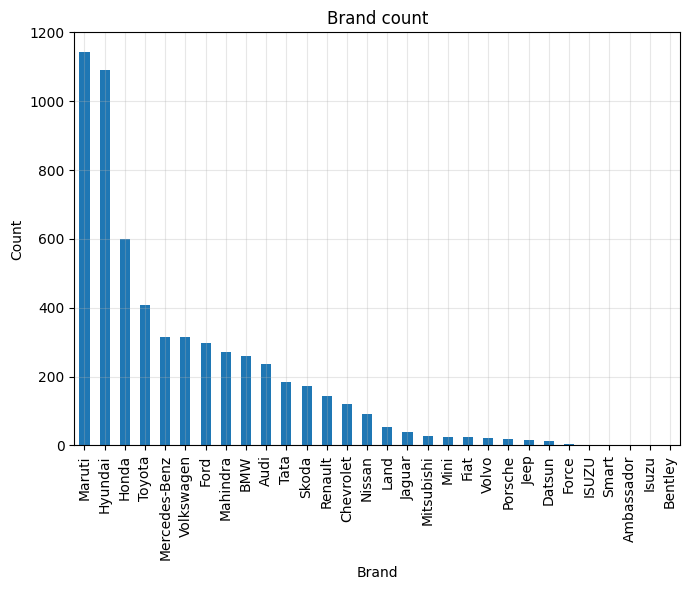

In [76]:
plt.figure(figsize=(7,6))
dataf['Brand'].value_counts().plot(kind='bar')
plt.title('Brand count')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
(dataf['Brand']=="Jeep").sum()

np.int64(15)

# suppression des marque en dessous de 15 vehicules

In [86]:
counts = dataf['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = dataf[dataf['Brand'].isin(brands_to_drop)].index
dataf = dataf.drop(rows_to_drop)

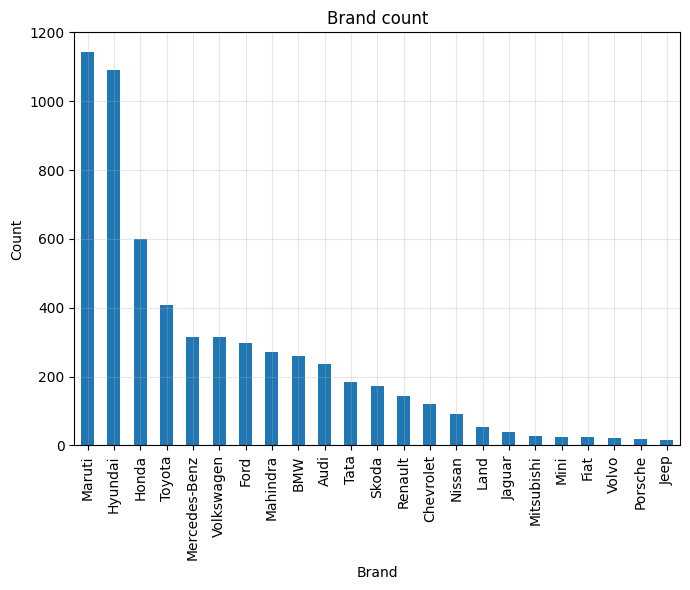

In [87]:
plt.figure(figsize=(7,6))
dataf['Brand'].value_counts().plot(kind='bar')
plt.title('Brand count')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
dataf.info()

<class 'pandas.DataFrame'>
Index: 5878 entries, 1 to 5974
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      5878 non-null   str    
 1   Fuel_Type     5878 non-null   str    
 2   Transmission  5878 non-null   str    
 3   Owner_Type    5878 non-null   str    
 4   Consumation   5878 non-null   float64
 5   Seats         5878 non-null   int64  
 6   Price         5878 non-null   float64
 7   Brand         5878 non-null   str    
 8   Model         5878 non-null   str    
 9   car_age       5878 non-null   int64  
 10  power/horse   5878 non-null   float64
dtypes: float64(3), int64(2), str(6)
memory usage: 551.1 KB


In [89]:
dataf.to_csv('HCengineered.csv', index=False)

# **break**

# **break**

# **break**

In [155]:
datac=pd.read_csv(r'Data\data_to_train.csv', sep=',')

In [156]:
datac.info()

<class 'pandas.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5975 non-null   str    
 1   Year               5975 non-null   int64  
 2   Kilometers_Driven  5975 non-null   int64  
 3   Fuel_Type          5975 non-null   str    
 4   Transmission       5975 non-null   str    
 5   Owner_Type         5975 non-null   str    
 6   Consumation        5975 non-null   float64
 7   Engine             5975 non-null   int64  
 8   Power              5975 non-null   float64
 9   Seats              5975 non-null   int64  
 10  Price              5975 non-null   float64
 11  Brand              5975 non-null   str    
 12  Model              5975 non-null   str    
 13  car_age            5975 non-null   int64  
 14  km/age             5975 non-null   float64
dtypes: float64(4), int64(5), str(6)
memory usage: 700.3 KB


In [157]:
datac.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Consumation,Engine,Power,Seats,Price,Brand,Model,car_age,km/age
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5,1.75,Maruti,Wagon R LXI CNG,16,4500.000000
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5,12.50,Hyundai,Creta 1.6 CRDi SX Option,11,3727.272727
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5,4.50,Honda,Jazz V,15,3066.666667
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7,6.00,Maruti,Ertiga VDI,14,6214.285714
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5,17.74,Audi,A4 New 2.0 TDI Multitronic,13,3128.461538


In [158]:
datac.drop(columns=['car_age',"Kilometers_Driven","km/age","Power"], inplace=True)

In [159]:
datac.head()

,Location,Year,Fuel_Type,Transmission,Owner_Type,Consumation,Engine,Seats,Price,Brand,Model
0,Mumbai,2010,CNG,Manual,First,26.60,998,5,1.75,Maruti,Wagon R LXI CNG
1,Pune,2015,Diesel,Manual,First,19.67,1582,5,12.50,Hyundai,Creta 1.6 CRDi SX Option
2,Chennai,2011,Petrol,Manual,First,18.20,1199,5,4.50,Honda,Jazz V
3,Chennai,2012,Diesel,Manual,First,20.77,1248,7,6.00,Maruti,Ertiga VDI
4,Coimbatore,2013,Diesel,Automatic,Second,15.20,1968,5,17.74,Audi,A4 New 2.0 TDI Multitronic


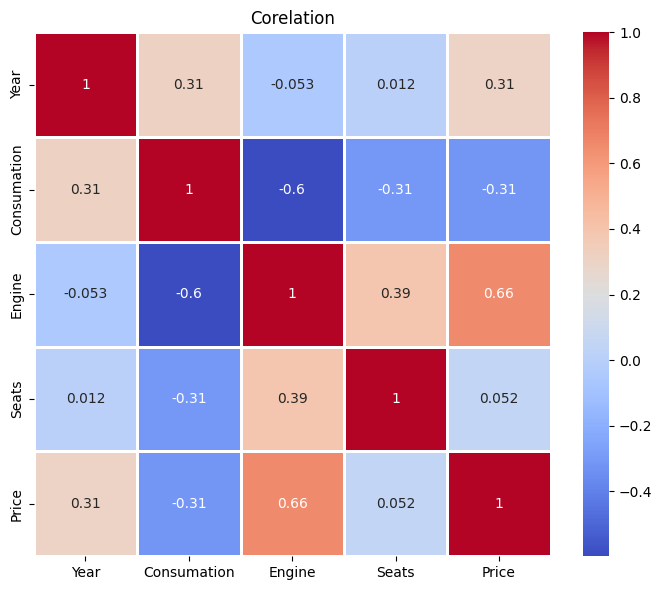

In [160]:
cor = datac.corr(numeric_only=True)
plt.figure(figsize=(7,6))
sns.heatmap(cor , 
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            # cbar_kws={'shrink': 0.8}
            )
plt.title('Corelation')
plt.tight_layout()
plt.show()

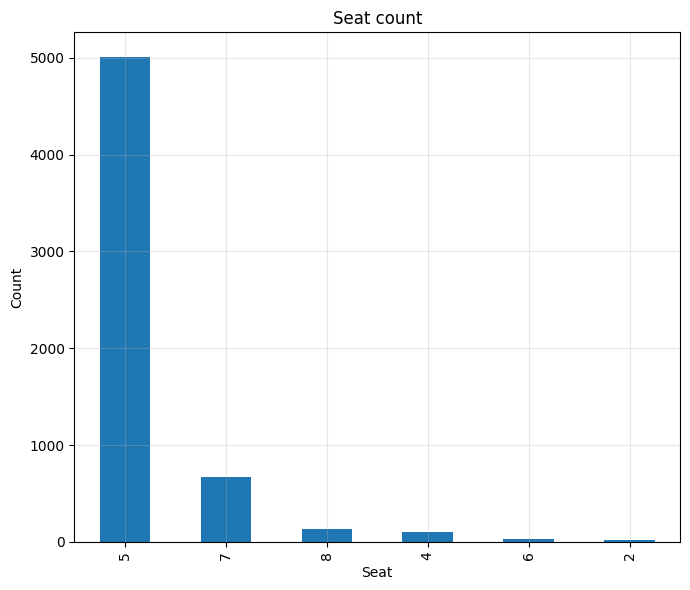

In [166]:
plt.figure(figsize=(7,6))
datac['Seats'].value_counts().plot(kind='bar')
plt.title('Seat count')
plt.xlabel('Seat')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [165]:

datac = datac.drop(datac[datac['Seats'] == 0].index)


In [167]:
datac.info()

<class 'pandas.DataFrame'>
Index: 5966 entries, 0 to 5974
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      5966 non-null   str    
 1   Year          5966 non-null   int64  
 2   Fuel_Type     5966 non-null   str    
 3   Transmission  5966 non-null   str    
 4   Owner_Type    5966 non-null   str    
 5   Consumation   5966 non-null   float64
 6   Engine        5966 non-null   int64  
 7   Seats         5966 non-null   int64  
 8   Price         5966 non-null   float64
 9   Brand         5966 non-null   str    
 10  Model         5966 non-null   str    
dtypes: float64(2), int64(3), str(6)
memory usage: 559.3 KB


In [168]:
datac.to_csv('HCengineeredseat.csv', index=False)

# **break**

In [178]:
datad=pd.read_csv(r'Data\data_to_train.csv', sep=',')

In [179]:
datad= datad.drop(datad[datad['Price'] > 80].index)

In [180]:
datad.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Consumation,Engine,Power,Seats,Price,Brand,Model,car_age,km/age
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5,1.75,Maruti,Wagon R LXI CNG,16,4500.000000
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5,12.50,Hyundai,Creta 1.6 CRDi SX Option,11,3727.272727
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5,4.50,Honda,Jazz V,15,3066.666667
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7,6.00,Maruti,Ertiga VDI,14,6214.285714
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5,17.74,Audi,A4 New 2.0 TDI Multitronic,13,3128.461538


In [181]:
datad.drop(columns=['car_age',"Kilometers_Driven","km/age","Power"], inplace=True)

In [184]:
datad.head()

,Location,Year,Fuel_Type,Transmission,Owner_Type,Consumation,Engine,Seats,Price,Brand,Model
0,Mumbai,2010,CNG,Manual,First,26.60,998,5,1.75,Maruti,Wagon R LXI CNG
1,Pune,2015,Diesel,Manual,First,19.67,1582,5,12.50,Hyundai,Creta 1.6 CRDi SX Option
2,Chennai,2011,Petrol,Manual,First,18.20,1199,5,4.50,Honda,Jazz V
3,Chennai,2012,Diesel,Manual,First,20.77,1248,7,6.00,Maruti,Ertiga VDI
4,Coimbatore,2013,Diesel,Automatic,Second,15.20,1968,5,17.74,Audi,A4 New 2.0 TDI Multitronic


In [185]:
datad.info()

<class 'pandas.DataFrame'>
Index: 5966 entries, 0 to 5974
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      5966 non-null   str    
 1   Year          5966 non-null   int64  
 2   Fuel_Type     5966 non-null   str    
 3   Transmission  5966 non-null   str    
 4   Owner_Type    5966 non-null   str    
 5   Consumation   5966 non-null   float64
 6   Engine        5966 non-null   int64  
 7   Seats         5966 non-null   int64  
 8   Price         5966 non-null   float64
 9   Brand         5966 non-null   str    
 10  Model         5966 non-null   str    
dtypes: float64(2), int64(3), str(6)
memory usage: 559.3 KB


In [186]:
datad.to_csv('engineeredlite.csv', index=False)

# **break**

In [187]:
datag=pd.read_csv(r'Data\data_to_train.csv', sep=',')

In [188]:
datag = datag.drop(datag[datag['Price'] > 80].index)

In [189]:
datag.to_csv('base_moins_80.csv', index=False)

# **break**

In [218]:
datak=pd.read_csv(r'Data\data_to_train.csv', sep=',')

In [219]:
counts = datak['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = datak[datak['Brand'].isin(brands_to_drop)].index
datak = datak.drop(rows_to_drop)

In [220]:
datak.drop(datak.loc[datak['Fuel_Type'] == 'CNG'].index, inplace=True)
datak.drop(datak.loc[datak['Fuel_Type'] == 'LPG'].index, inplace=True)

In [221]:
datak.drop(columns=["Engine","Year","Kilometers_Driven","km/age"], inplace=True)

In [222]:
datak.info()

<class 'pandas.DataFrame'>
Index: 5886 entries, 1 to 5974
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      5886 non-null   str    
 1   Fuel_Type     5886 non-null   str    
 2   Transmission  5886 non-null   str    
 3   Owner_Type    5886 non-null   str    
 4   Consumation   5886 non-null   float64
 5   Power         5886 non-null   float64
 6   Seats         5886 non-null   int64  
 7   Price         5886 non-null   float64
 8   Brand         5886 non-null   str    
 9   Model         5886 non-null   str    
 10  car_age       5886 non-null   int64  
dtypes: float64(3), int64(2), str(6)
memory usage: 551.8 KB


In [223]:
power_capped = np.clip(datak[['Power']], a_min=0, a_max=500)
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')

datak['Power_bins'] = kbd.fit_transform(power_capped).astype(int)

In [224]:
datak.drop(columns=["Power","Seats"], inplace=True)

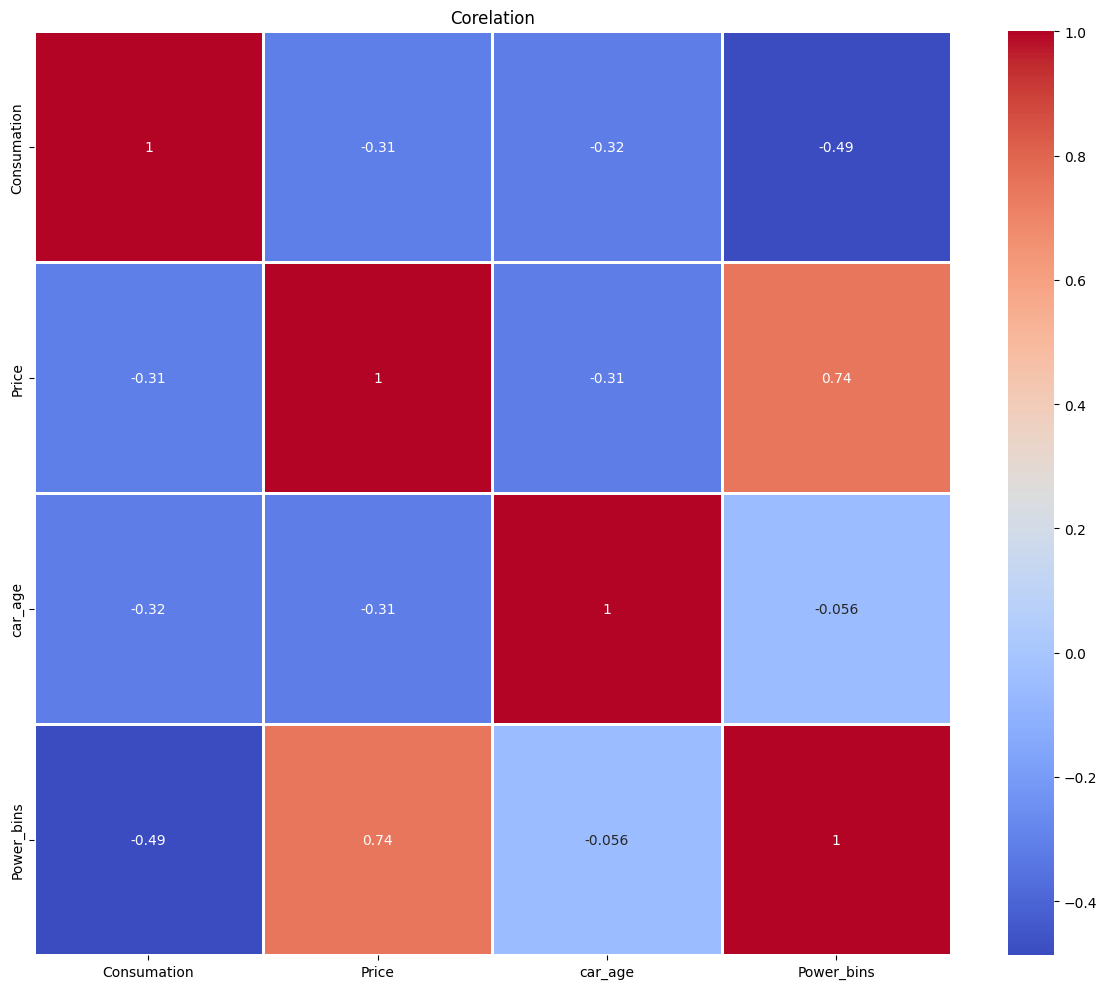

In [225]:
cor = datak.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(cor , 
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            # cbar_kws={'shrink': 0.8}
            )
plt.title('Corelation')
plt.tight_layout()
plt.show()

In [226]:
index =  datak[datak["Consumation"] < 5 ].index
datak.drop(index,inplace = True)

In [227]:
index =  datak[datak["Consumation"] > 29 ].index
datak.drop(index,inplace = True)

In [230]:
datak.to_csv('fusion.csv', index=False)

In [231]:
datak.info()

<class 'pandas.DataFrame'>
Index: 5831 entries, 1 to 5974
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      5831 non-null   str    
 1   Fuel_Type     5831 non-null   str    
 2   Transmission  5831 non-null   str    
 3   Owner_Type    5831 non-null   str    
 4   Consumation   5831 non-null   float64
 5   Price         5831 non-null   float64
 6   Brand         5831 non-null   str    
 7   Model         5831 non-null   str    
 8   car_age       5831 non-null   int64  
 9   Power_bins    5831 non-null   int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 501.1 KB


# **break**

In [2]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

In [3]:
datat_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   str    
 1   Location           6019 non-null   str    
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   str    
 5   Transmission       6019 non-null   str    
 6   Owner_Type         6019 non-null   str    
 7   Mileage            6017 non-null   str    
 8   Engine             5983 non-null   str    
 9   Power              5983 non-null   str    
 10  Seats              5977 non-null   float64
 11  New_Price          824 non-null    str    
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), str(9)
memory usage: 611.4 KB


In [4]:
data_clean=datat_train.drop(columns=('New_Price'))

In [5]:
pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

In [6]:
Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

In [7]:
imputer = knn(n_neighbors=5)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

In [8]:
data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

In [78]:
data_clean.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Model,Brand
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,Wagon R LXI CNG,Maruti
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Creta 1.6 CRDi SX Option,Hyundai
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,Jazz V,Honda
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,Ertiga VDI,Maruti
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,A4 New 2.0 TDI Multitronic,Audi


In [79]:
data_clean.isna().sum()

Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              2
Engine               0
Power                0
Seats                0
Price                0
Model                0
Brand                0
dtype: int64

In [80]:
data_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           6019 non-null   str    
 1   Year               6019 non-null   int64  
 2   Kilometers_Driven  6019 non-null   int64  
 3   Fuel_Type          6019 non-null   str    
 4   Transmission       6019 non-null   str    
 5   Owner_Type         6019 non-null   str    
 6   Mileage            6017 non-null   float64
 7   Engine             6019 non-null   float64
 8   Power              6019 non-null   float64
 9   Seats              6019 non-null   float64
 10  Price              6019 non-null   float64
 11  Model              6019 non-null   str    
 12  Brand              6019 non-null   str    
dtypes: float64(5), int64(2), str(6)
memory usage: 611.4 KB


In [9]:
data_clean.dropna( inplace= True)

In [82]:
data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].count()

Location             56
Year                 56
Kilometers_Driven    56
Fuel_Type            56
Transmission         56
Owner_Type           56
Mileage              56
Engine               56
Power                56
Seats                56
Price                56
Model                56
Brand                56
dtype: int64

In [83]:
data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].count()

Location             10
Year                 10
Kilometers_Driven    10
Fuel_Type            10
Transmission         10
Owner_Type           10
Mileage              10
Engine               10
Power                10
Seats                10
Price                10
Model                10
Brand                10
dtype: int64

In [84]:
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

In [10]:
counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

In [11]:
data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)

In [12]:
index =  data__[data__["Mileage"] > 29 ].index
data__.drop(index,inplace = True)
index =  data__[data__["Mileage"] < 5 ].index
data__.drop(index,inplace = True)

In [13]:
power_capped = np.clip(data__[['Power']], a_min=0, a_max=500)
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')

data__['Power_bins'] = kbd.fit_transform(power_capped).astype(int)

In [14]:
data__.info()

<class 'pandas.DataFrame'>
Index: 5825 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5825 non-null   str    
 1   Year               5825 non-null   int64  
 2   Kilometers_Driven  5825 non-null   int64  
 3   Fuel_Type          5825 non-null   str    
 4   Transmission       5825 non-null   str    
 5   Owner_Type         5825 non-null   str    
 6   Mileage            5825 non-null   float64
 7   Engine             5825 non-null   float64
 8   Power              5825 non-null   float64
 9   Seats              5825 non-null   float64
 10  Price              5825 non-null   float64
 11  Model              5825 non-null   str    
 12  Brand              5825 non-null   str    
 13  Power_bins         5825 non-null   int64  
dtypes: float64(5), int64(3), str(6)
memory usage: 682.6 KB


In [15]:
data__.drop(columns=['Kilometers_Driven','Seats'], inplace=True)

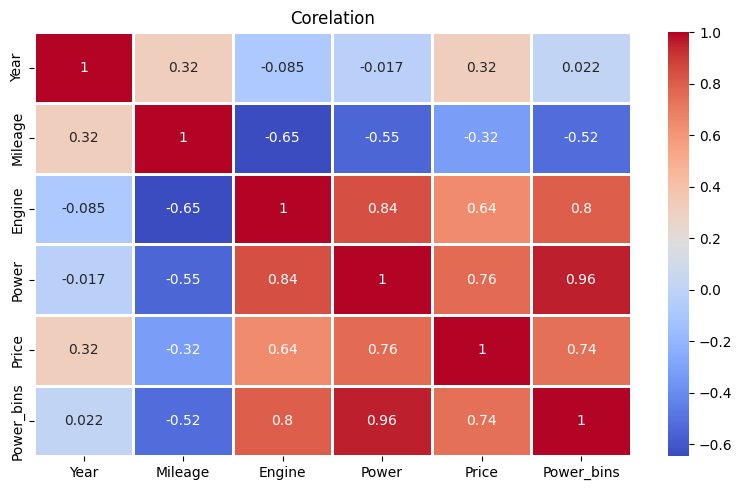

In [16]:
cor = data__.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(cor , 
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            # cbar_kws={'shrink': 0.8}
            )
plt.title('Corelation')
plt.tight_layout()
plt.show()

In [17]:
data__.to_csv('RErengineered.csv', index=False)

# **break**

In [ ]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

data_clean=datat_train.drop(columns=('New_Price'))

pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

imputer = knn(n_neighbors=5)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

data_clean.dropna( inplace= True)

data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)

index =  data__[data__["Mileage"] > 29 ].index
data__.drop(index,inplace = True)
index =  data__[data__["Mileage"] < 5 ].index
data__.drop(index,inplace = True)

power_capped = np.clip(data__[['Power']], a_min=0, a_max=500)
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')

data__['Power_bins'] = kbd.fit_transform(power_capped).astype(int)

data__.drop(columns=['Kilometers_Driven','Seats'], inplace=True)

data__.to_csv('RErengineered.csv', index=False)

/////////

In [ ]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

data_clean=datat_train.drop(columns=('New_Price'))

pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

imputer = knn(n_neighbors=10)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

data_clean.dropna( inplace= True)

data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)


power_capped = np.clip(data__[['Power']], a_min=0, a_max=500)
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')

data__['Power_bins'] = kbd.fit_transform(power_capped).astype(int)

data__.drop(columns=['Kilometers_Driven','Seats','Mileage'], inplace=True)

print(data__.info())
data__.head()


# data__.to_csv('REfengineered.csv', index=False)

<class 'pandas.DataFrame'>
Index: 5840 entries, 1 to 6018
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      5840 non-null   str    
 1   Year          5840 non-null   int64  
 2   Fuel_Type     5840 non-null   str    
 3   Transmission  5840 non-null   str    
 4   Owner_Type    5840 non-null   str    
 5   Engine        5840 non-null   float64
 6   Power         5840 non-null   float64
 7   Price         5840 non-null   float64
 8   Model         5840 non-null   str    
 9   Brand         5840 non-null   str    
 10  Power_bins    5840 non-null   int64  
dtypes: float64(3), int64(2), str(6)
memory usage: 547.5 KB
None


,Year,Engine,Power,Price,Power_bins
count,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.307363,1605.445540,111.399207,8.704271,1.154110
std,3.267890,565.148978,48.720410,8.719476,1.095328
min,1998.000000,624.000000,34.200000,0.440000,0.000000
25%,2011.000000,1198.000000,78.900000,3.500000,0.000000
50%,2014.000000,1493.000000,98.600000,5.600000,1.000000
75%,2016.000000,1968.000000,136.000000,9.600000,2.000000
max,2019.000000,5461.000000,550.000000,50.000000,9.000000


//////////////////

In [9]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

data_clean=datat_train.drop(columns=('New_Price'))

pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

imputer = knn(n_neighbors=5)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

data_clean['Engine']=data_clean['Engine'].astype(int)
data_clean['Seats']=data_clean['Seats'].astype(int)

data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

data_clean.dropna( inplace= True)

data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

index = data_clean[data_clean['Kilometers_Driven']>1000000].index
data_clean.drop(index, inplace=True)

data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)

index =  data__[data__["Mileage"] > 29 ].index
data__.drop(index,inplace = True)
index =  data__[data__["Mileage"] < 5 ].index
data__.drop(index,inplace = True)


data__.drop(columns=['Seats','Power'], inplace=True)

print(data__.info())
data__.head()

data__.to_csv('REkengineered.csv', index=False)

<class 'pandas.DataFrame'>
Index: 5773 entries, 1 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5773 non-null   str    
 1   Year               5773 non-null   int64  
 2   Kilometers_Driven  5773 non-null   int64  
 3   Fuel_Type          5773 non-null   str    
 4   Transmission       5773 non-null   str    
 5   Owner_Type         5773 non-null   str    
 6   Mileage            5773 non-null   float64
 7   Engine             5773 non-null   int64  
 8   Price              5773 non-null   float64
 9   Model              5773 non-null   str    
 10  Brand              5773 non-null   str    
dtypes: float64(2), int64(3), str(6)
memory usage: 541.2 KB
None


///////////////////////////

In [ ]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

data_clean=datat_train.drop(columns=('New_Price'))

pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

imputer = knn(n_neighbors=10)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

data_clean.dropna( inplace= True)

data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)


power_capped = np.clip(data__[['Power']], a_min=0, a_max=350)
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')

data__['Power_bins'] = kbd.fit_transform(power_capped).astype(int)

engi_capped = np.clip(data__[['Engine']], a_min=0, a_max=3000)
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')

data__['Engine_bins'] = kbd.fit_transform(engi_capped).astype(int)

data__.drop(columns=['Kilometers_Driven','Seats','Mileage','Power','Engine'], inplace=True)

print(data__.info())
data__.head()

data__.to_csv('REmengineered.csv', index=False)

<class 'pandas.DataFrame'>
Index: 5840 entries, 1 to 6018
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      5840 non-null   str    
 1   Year          5840 non-null   int64  
 2   Fuel_Type     5840 non-null   str    
 3   Transmission  5840 non-null   str    
 4   Owner_Type    5840 non-null   str    
 5   Price         5840 non-null   float64
 6   Model         5840 non-null   str    
 7   Brand         5840 non-null   str    
 8   Power_bins    5840 non-null   int64  
 9   Engine_bins   5840 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 501.9 KB
None


//////////////////////////////////////

In [14]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

data_clean=datat_train.drop(columns=('New_Price'))

pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

imputer = knn(n_neighbors=5)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

data_clean['Engine']=data_clean['Engine'].astype(int)
data_clean['Seats']=data_clean['Seats'].astype(int)

data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

data_clean.dropna( inplace= True)

data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

index = data_clean[data_clean['Kilometers_Driven']>1000000].index
data_clean.drop(index, inplace=True)

data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)

index =  data__[data__["Mileage"] > 29 ].index
data__.drop(index,inplace = True)
index =  data__[data__["Mileage"] < 5 ].index
data__.drop(index,inplace = True)

data__ = data__.drop(data__.loc[data__['Seats'] == 0].index)
data__ = data__.drop(data__.loc[data__['Seats'] == 2].index)

data__.drop(columns=['Power'], inplace=True)

print(data__.info())
data__.head()

data__.to_csv('REpengineered.csv', index=False)

<class 'pandas.DataFrame'>
Index: 5766 entries, 1 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5766 non-null   str    
 1   Year               5766 non-null   int64  
 2   Kilometers_Driven  5766 non-null   int64  
 3   Fuel_Type          5766 non-null   str    
 4   Transmission       5766 non-null   str    
 5   Owner_Type         5766 non-null   str    
 6   Mileage            5766 non-null   float64
 7   Engine             5766 non-null   int64  
 8   Seats              5766 non-null   int64  
 9   Price              5766 non-null   float64
 10  Model              5766 non-null   str    
 11  Brand              5766 non-null   str    
dtypes: float64(2), int64(4), str(6)
memory usage: 585.6 KB
None


///////////////////////

In [ ]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

data_clean=datat_train.drop(columns=('New_Price'))

pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

imputer = knn(n_neighbors=5)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

data_clean['Engine']=data_clean['Engine'].astype(int)
data_clean['Seats']=data_clean['Seats'].astype(int)

data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

data_clean.dropna( inplace= True)

data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

index = data_clean[data_clean['Kilometers_Driven']>1000000].index
data_clean.drop(index, inplace=True)

data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)

index =  data__[data__["Mileage"] > 29 ].index
data__.drop(index,inplace = True)
index =  data__[data__["Mileage"] < 5 ].index
data__.drop(index,inplace = True)

data__ = data__.drop(data__.loc[data__['Seats'] == 0].index)
data__ = data__.drop(data__.loc[data__['Seats'] == 2].index)

engi_capped = np.clip(data__[['Engine']], a_min=0, a_max=3000)
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
data__['Engine_bins'] = kbd.fit_transform(engi_capped).astype(int)

data__.drop(columns=['Power','Engine'], inplace=True)

print(data__.info())
data__.head()

data__.to_csv('REgengineered.csv', index=False)

////////////////////////////

In [15]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

data_clean=datat_train.drop(columns=('New_Price'))

pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

imputer = knn(n_neighbors=5)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

data_clean['Engine']=data_clean['Engine'].astype(int)
data_clean['Seats']=data_clean['Seats'].astype(int)

data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

data_clean.dropna( inplace= True)

data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

index = data_clean[data_clean['Kilometers_Driven']>1000000].index
data_clean.drop(index, inplace=True)

data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)

index =  data__[data__["Mileage"] > 29 ].index
data__.drop(index,inplace = True)
index =  data__[data__["Mileage"] < 5 ].index
data__.drop(index,inplace = True)


data__.drop(columns=['Seats','Power'], inplace=True)

print(data__.info())
data__.head()

data__.to_csv('Fengineered.csv', index=False)

<class 'pandas.DataFrame'>
Index: 5773 entries, 1 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5773 non-null   str    
 1   Year               5773 non-null   int64  
 2   Kilometers_Driven  5773 non-null   int64  
 3   Fuel_Type          5773 non-null   str    
 4   Transmission       5773 non-null   str    
 5   Owner_Type         5773 non-null   str    
 6   Mileage            5773 non-null   float64
 7   Engine             5773 non-null   int64  
 8   Price              5773 non-null   float64
 9   Model              5773 non-null   str    
 10  Brand              5773 non-null   str    
dtypes: float64(2), int64(3), str(6)
memory usage: 541.2 KB
None


////////////////////////////

In [18]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

data_clean=datat_train.drop(columns=('New_Price'))

pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

imputer = knn(n_neighbors=5)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

data_clean['Engine']=data_clean['Engine'].astype(int)
data_clean['Seats']=data_clean['Seats'].astype(int)

data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

data_clean.dropna( inplace= True)

data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

index = data_clean[data_clean['Kilometers_Driven']>1000000].index
data_clean.drop(index, inplace=True)

data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)

index =  data__[data__["Mileage"] > 29 ].index
data__.drop(index,inplace = True)
index =  data__[data__["Mileage"] < 5 ].index
data__.drop(index,inplace = True)


data__.drop(columns=['Seats','Power'], inplace=True)


data__ = data__.drop(data__[(data__['Owner_Type'] == 'Second') & (data__['Price'] > 40)].index)
data__ = data__.drop(data__[(data__['Owner_Type'] == 'Third') & (data__['Price'] > 10)].index)

print(data__.info())
data__.head()

data__.to_csv('hengineered.csv', index=False)

<class 'pandas.DataFrame'>
Index: 5760 entries, 1 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5760 non-null   str    
 1   Year               5760 non-null   int64  
 2   Kilometers_Driven  5760 non-null   int64  
 3   Fuel_Type          5760 non-null   str    
 4   Transmission       5760 non-null   str    
 5   Owner_Type         5760 non-null   str    
 6   Mileage            5760 non-null   float64
 7   Engine             5760 non-null   int64  
 8   Price              5760 non-null   float64
 9   Model              5760 non-null   str    
 10  Brand              5760 non-null   str    
dtypes: float64(2), int64(3), str(6)
memory usage: 540.0 KB
None


In [19]:
datat_train=pd.read_csv(r"data\train.csv",sep=',')

data_clean=datat_train.drop(columns=('New_Price'))

pow=data_clean[data_clean['Power']=='null bhp'].index
data_clean.loc[pow, 'Power']=np.nan

Dirty_col = ['Mileage','Engine', 'Power']
for col in Dirty_col:
    data_clean[col] = data_clean[col].apply(lambda x : float(x.split()[0]) if isinstance(x, str) else float(x))

imputer = knn(n_neighbors=5)
data_clean['Power']=imputer.fit_transform(data_clean[['Power']])
data_clean['Seats']=imputer.fit_transform(data_clean[['Seats']])
data_clean['Engine']=imputer.fit_transform(data_clean[['Engine']])

data_clean['Engine']=data_clean['Engine'].astype(int)
data_clean['Seats']=data_clean['Seats'].astype(int)

data_clean['Model'] = data_clean['Name'].apply(lambda x:" " .join(x.split()[1:]))
data_clean['Brand'] = data_clean['Name'].apply(lambda x: x.split()[0])
data_clean.drop(columns=['Name'], inplace=True)

data_clean.dropna( inplace= True)

data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'CNG'].index, inplace=True)
data_clean.drop(data_clean.loc[data_clean['Fuel_Type'] == 'LPG'].index, inplace=True)

counts = data_clean['Brand'].value_counts()
brands_to_drop = counts[counts < 15].index
rows_to_drop = data_clean[data_clean['Brand'].isin(brands_to_drop)].index
data_clean = data_clean.drop(rows_to_drop)

index = data_clean[data_clean['Kilometers_Driven']>1000000].index
data_clean.drop(index, inplace=True)

data__ = data_clean.drop(data_clean[data_clean['Price'] > 50].index)

index =  data__[data__["Mileage"] > 29 ].index
data__.drop(index,inplace = True)
index =  data__[data__["Mileage"] < 5 ].index
data__.drop(index,inplace = True)

data__ = data__.drop(data__.loc[data__['Seats'] == 0].index)
data__ = data__.drop(data__.loc[data__['Seats'] == 2].index)

data__.drop(columns=['Power'], inplace=True)


data__ = data__.drop(data__[(data__['Owner_Type'] == 'Second') & (data__['Price'] > 40)].index)
data__ = data__.drop(data__[(data__['Owner_Type'] == 'Third') & (data__['Price'] > 10)].index)

print(data__.info())
data__.head()

data__.to_csv('dengineered.csv', index=False)

<class 'pandas.DataFrame'>
Index: 5753 entries, 1 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           5753 non-null   str    
 1   Year               5753 non-null   int64  
 2   Kilometers_Driven  5753 non-null   int64  
 3   Fuel_Type          5753 non-null   str    
 4   Transmission       5753 non-null   str    
 5   Owner_Type         5753 non-null   str    
 6   Mileage            5753 non-null   float64
 7   Engine             5753 non-null   int64  
 8   Seats              5753 non-null   int64  
 9   Price              5753 non-null   float64
 10  Model              5753 non-null   str    
 11  Brand              5753 non-null   str    
dtypes: float64(2), int64(4), str(6)
memory usage: 584.3 KB
None
